In [70]:
library(ggplot2)
library(dplyr)

In [71]:
setwd("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/sRNA_deseq/")

In [72]:
data <- read.csv("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/sRNA_deseq/data/all_peter_plot_AUGC.csv", header=TRUE,sep=';')


# Remove rows with NA values using na.omit
data <- na.omit(data)
# Define the desired order of Strains
desired_strains_order <- c('C57BL_6NJ', 'BALB_cJ', 'A_J', 'FVB_NJ', 'C3H_HeJ', 'LP_J', '129S1_SvImJ', 'DBA_2J', 'AKR_J', 'CBA_J', 'NZO_HlLtJ', 'NOD_ShiLtJ', 'WSB_EiJ', 'CAST_EiJ', 'PWK_PhJ', 'SPRET_EiJ')

# Define the desired order of Measure_Names based on unique, unique loci, and multi loci
desired_measure_order <- c( "A","C","G","T" )  # Replace with your order

# Define the desired order for Timepoint
desired_timepoint_order <- c("E16.5", "P12.5", "P20.5")

# Create a custom factor with the desired order for Timepoint
data$timepoint <- factor(data$timepoint, levels = desired_timepoint_order)


# Create a custom factor with the desired order for Measure_Names
data$Measure.Names <- factor(data$Measure.Names, levels = desired_measure_order)

# Create a custom factor with the desired order for Strains
data$Strains <- factor(data$Strains, levels = desired_strains_order)

# Define custom colors for stacked bars and error bars
stacked_bar_colors <- c( "#1f77b4","#2ca02c","#ff7f0e", "#d62728" ,'blue')  # Replace with your colors
error_bar_color <- "#000000"   # Replace with your color
data

,timepoint,replicates,length,Strains,Measure.Names,Measure.Values
,<fct>,<int>,<int>,<fct>,<fct>,<dbl>
1,E16.5,1,19,WSB_EiJ,A,0.000000000
2,E16.5,1,19,WSB_EiJ,C,0.000000000
3,E16.5,1,19,WSB_EiJ,G,0.000000000
4,E16.5,1,19,WSB_EiJ,T,0.000000000
5,E16.5,1,20,WSB_EiJ,A,0.002381983
6,E16.5,1,20,WSB_EiJ,C,0.000726765
7,E16.5,1,20,WSB_EiJ,G,0.002579511
8,E16.5,1,20,WSB_EiJ,T,0.001460424
9,E16.5,1,21,WSB_EiJ,A,0.001510275


In [73]:

# Checking for NA values
na_rows <- which(is.na(data$Measure.Values))
data <- data[-na_rows, ]
# Round the values in the Measure_Values column to two decimal places
data$Measure.Values <- round(data$Measure.Values, 2)

In [75]:
p <- ggbarplot(data,
          x = "length", y = "Measure.Values", 
          fill= "Measure.Names",
          add = "mean_se",
          width =0.1,
          add.params = list(color = "#000000"),
          size= 0.1,
          facet.by = c("Strains", "timepoint"), # Faceting by two columns
          error.plot = "errorbar") + 
  theme_pubr() +  # Apply ggpubr theme for consistency
  labs(x = "length", y = "%") +  # Customize axis labels
  scale_fill_manual(values = stacked_bar_colors) +  # Set custom fill colors  
  theme_minimal() +
   theme(axis.text.x = element_text(angle = 90, hjust = 1,size=6),
   strip.text.x = element_text(angle = 90, vjust = 0.5, hjust = 0.1))# Rotate x-axis labels for better readability


   # Set x-axis with actual values and define the range
#p_final <- p + scale_x_continuous(breaks = 23:35, limits = c(23, 34))

# Save the plot to a PDF
ggsave(filename = "U_peak_bar.pdf", plot = p, width = 6, height = 30)

Warning message in base::min(x, na.rm = TRUE):
“no non-missing arguments to min; returning Inf”
Warning message in base::max(x, na.rm = TRUE):
“no non-missing arguments to max; returning -Inf”
Warning message in stats::qt(ci/2 + 0.5, data_sum$length - 1):
“NaNs produced”
Warning message in max(.):
“no non-missing arguments to max; returning -Inf”


ERROR: [1m[33mError[39m in `combine_vars()`:[22m
[1m[22m[33m![39m Faceting variables must have at least one value


In [30]:
generate_plot <- function(data_subset) {
  ggbarplot(data,
          x = "length", y = "Measure.Values", 
          fill= "Measure.Names",
          add = "mean_se",
          width =0.8,
          add.params = list(color = "#000000"),
          facet.by = "Strains",
          ncol=1,
          size= 0.4,
          error.plot = "errorbar") + 
  theme_pubr() +  # Apply ggpubr theme for consistency
  labs(x = "length", y = "%") +  # Customize axis labels
  scale_fill_manual(values = stacked_bar_colors) +  # Set custom fill colors  
  theme_minimal() +
   theme(axis.text.x = element_text(angle = 0, hjust = 1,size=6),
   strip.text.x = element_text(angle = 0, vjust = 0.5, hjust = 0.1))# Rotate x-axis labels for better readability
}
pdf("combined_plots.pdf", width = 20, height = 40)  # Adjust the width and height as needed


pdf 
  3

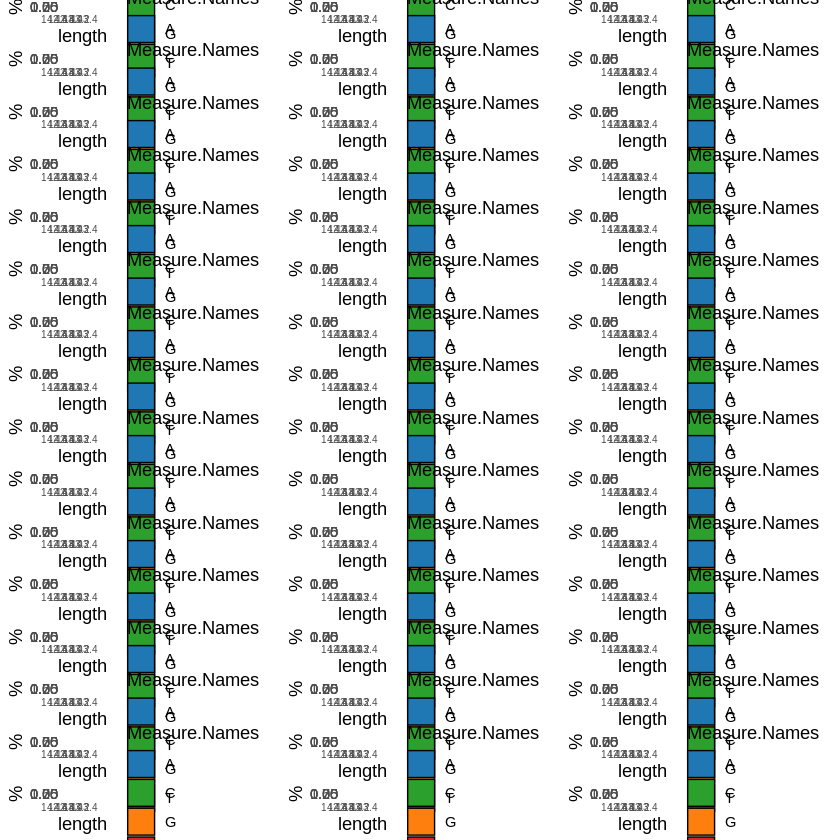

In [31]:
plot_list <- data %>%
  group_by(timepoint, Strains) %>%
  group_map(~ generate_plot(.x))

# Combine individual plots into a grid
combined_plots <- do.call(grid.arrange, c(plot_list, ncol = 3, nrow = 16))
dev.off()



In [9]:
# Remove rows with NA values using na.omit
summary_data <- na.omit(summary_data)
# Define the desired order of Strains
desired_strains_order <- c('C57BL_6NJ', 'BALB_cJ', 'A_J', 'FVB_NJ', 'C3H_HeJ', 'LP_J', '129S1_SvImJ', 'DBA_2J', 'AKR_J', 'CBA_J', 'NZO_HlLtJ', 'NOD_ShiLtJ', 'WSB_EiJ', 'CAST_EiJ', 'PWK_PhJ', 'SPRET_EiJ')

# Define the desired order of Measure_Names based on unique, unique loci, and multi loci
desired_measure_order <- c( "A","C","G","T" )  # Replace with your order

# Define the desired order for Timepoint
desired_timepoint_order <- c("E16.5", "P12.5", "P20.5")

In [10]:
# Create a custom factor with the desired order for Timepoint
summary_data$timepoint <- factor(summary_data$timepoint, levels = desired_timepoint_order)


# Create a custom factor with the desired order for Measure_Names
summary_data$Measure.Names <- factor(summary_data$Measure.Names, levels = desired_measure_order)

# Create a custom factor with the desired order for Strains
summary_data$Strains <- factor(summary_data$Strains, levels = desired_strains_order)

# Define custom colors for stacked bars and error bars
stacked_bar_colors <- c( "#1f77b4","#2ca02c","#ff7f0e", "#d62728" ,'blue')  # Replace with your colors
error_bar_color <- "#000000"   # Replace with your color
summary_data


timepoint,length,Strains,Measure.Names,Mean,SE
<fct>,<int>,<fct>,<fct>,<dbl>,<dbl>
E16.5,19,129S1_SvImJ,A,0,0
E16.5,19,129S1_SvImJ,C,0,0
E16.5,19,129S1_SvImJ,G,0,0
E16.5,19,129S1_SvImJ,T,0,0
E16.5,19,AKR_J,A,0,0
E16.5,19,AKR_J,C,0,0
E16.5,19,AKR_J,G,0,0
E16.5,19,AKR_J,T,0,0
E16.5,19,A_J,A,0,0


In [12]:
# Load the required libraries
library(ggpubr)
# Your existing code for reading and preprocessing data here...
# Create the stacked bar plot with error bars using ggbarplot
plot <- ggbarplot(data,
          x = "length", y = "Measure.Values", 
          fill= "Measure.Names",
          add = "mean_se",
          width =0.8,
          add.params = list(color = "#000000"),
          nrow =16,
          ncol=3,
          size= 0.4,
          error.plot = "errorbar",
          title = "piRNA U peak") + 
  theme_pubr() +  # Apply ggpubr theme for consistency
  labs(x = "length", y = "%") +  # Customize axis labels
  scale_fill_manual(values = stacked_bar_colors) +  # Set custom fill colors  
  theme_minimal() +
   theme(axis.text.x = element_text(angle = 90, hjust = 1,size=6),
   strip.text.x = element_text(angle = 90, vjust = 0.5, hjust = 0.1))# Rotate x-axis labels for better readability
 
plot

ERROR: [1m[33mError[39m in `purrr::pmap()`:[22m
[1m[22m[36mℹ[39m In index: 1.
[36mℹ[39m With name: Measure.Values.
[1mCaused by error in `FUN()`:[22m
[1m[22m[33m![39m Can't convert a <formula> object to a symbol.
